# Introduction

Since Jan. 1, 2015, [The Washington Post](https://www.washingtonpost.com/) has been compiling a database of every fatal shooting in the US by a police officer in the line of duty.

<center><img src=https://i.imgur.com/sX3K62b.png></center>

While there are many challenges regarding data collection and reporting, The Washington Post has been tracking more than a dozen details about each killing. This includes the race, age and gender of the deceased, whether the person was armed, and whether the victim was experiencing a mental-health crisis. The Washington Post has gathered this supplemental information from law enforcement websites, local new reports, social media, and by monitoring independent databases such as "Killed by police" and "Fatal Encounters". The Post has also conducted additional reporting in many cases.

There are 4 additional datasets: US census data on poverty rate, high school graduation rate, median household income, and racial demographics. [Source of census data](https://factfinder.census.gov/faces/nav/jsf/pages/community_facts.xhtml).

### Upgrade Plotly

Run the cell below if you are working with Google Colab

In [1]:
%pip install --upgrade plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 79.9 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


## Import Statements

In [2]:
import numpy as np
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns

# This might be helpful:
from collections import Counter

## Notebook Presentation

In [3]:
pd.options.display.float_format = '{:,.2f}'.format

## Load the Data

In [4]:
df_hh_income = pd.read_csv('Median_Household_Income_2015.csv', encoding="windows-1252")
df_pct_poverty = pd.read_csv('Pct_People_Below_Poverty_Level.csv', encoding="windows-1252")
df_pct_completed_hs = pd.read_csv('Pct_Over_25_Completed_High_School.csv', encoding="windows-1252")
df_share_race_city = pd.read_csv('Share_of_Race_By_City.csv', encoding="windows-1252")
df_fatalities = pd.read_csv('Deaths_by_Police_US.csv', encoding="windows-1252")

# Preliminary Data Exploration

* What is the shape of the DataFrames?
* How many rows and columns do they have?
* What are the column names?
* Are there any NaN values or duplicates?

In [5]:
print(f'Shape of df_hh_income dataset is: {df_hh_income.shape[0]} rows and {df_hh_income.shape[1]} columns ')
print(f'Shape of df_pct_poverty dataset is: {df_pct_poverty.shape[0]} rows and {df_pct_poverty.shape[1]} columns ')
print(f'Shape of df_pct_completed_hs dataset is: {df_pct_completed_hs.shape[0]} rows and {df_pct_completed_hs.shape[1]} columns ')
print(f'Shape of df_share_race_city dataset is: {df_share_race_city.shape[0]} rows and {df_share_race_city.shape[1]} columns ')
print(f'Shape of df_fatalities dataset is: {df_fatalities.shape[0]} rows and {df_fatalities.shape[1]} columns ')

Shape of df_hh_income dataset is: 29322 rows and 3 columns 
Shape of df_pct_poverty dataset is: 29329 rows and 3 columns 
Shape of df_pct_completed_hs dataset is: 29329 rows and 3 columns 
Shape of df_share_race_city dataset is: 29268 rows and 7 columns 
Shape of df_fatalities dataset is: 2535 rows and 14 columns 


In [6]:
print(f'In dataset df_hh_income there are following columns: {df_hh_income.columns}')
print(f'In dataset df_pct_poverty there are following columns: {df_pct_poverty.columns}')
print(f'In dataset df_pct_completed_hs there are following columns: {df_pct_completed_hs.columns}')
print(f'In dataset df_share_race_city there are following columns: {df_share_race_city.columns}')
print(f'In dataset df_fatalities there are  following columns: {df_fatalities.columns}')

In dataset df_hh_income there are following columns: Index(['Geographic Area', 'City', 'Median Income'], dtype='object')
In dataset df_pct_poverty there are following columns: Index(['Geographic Area', 'City', 'poverty_rate'], dtype='object')
In dataset df_pct_completed_hs there are following columns: Index(['Geographic Area', 'City', 'percent_completed_hs'], dtype='object')
In dataset df_share_race_city there are following columns: Index(['Geographic area', 'City', 'share_white', 'share_black',
       'share_native_american', 'share_asian', 'share_hispanic'],
      dtype='object')
In dataset df_fatalities there are  following columns: Index(['id', 'name', 'date', 'manner_of_death', 'armed', 'age', 'gender',
       'race', 'city', 'state', 'signs_of_mental_illness', 'threat_level',
       'flee', 'body_camera'],
      dtype='object')


## Data Cleaning - Check for Missing Values and Duplicates

Consider how to deal with the NaN values. Perhaps substituting 0 is appropriate.

In [7]:
print(f"Are there any NAN values in this dataset?:{df_hh_income.isna().values.any()}")
print(f"Are there any NAN values in this dataset?:{df_pct_poverty.isna().values.any()}")
print(f"Are there any NAN values in this dataset?:{df_pct_completed_hs.isna().values.any()}")
print(f"Are there any NAN values in this dataset?:{df_share_race_city.isna().values.any()}")
print(f"Are there any NAN values in this dataset?:{df_fatalities.isna().values.any()}")

Are there any NAN values in this dataset?:True
Are there any NAN values in this dataset?:False
Are there any NAN values in this dataset?:False
Are there any NAN values in this dataset?:False
Are there any NAN values in this dataset?:True


In [8]:
print(f"Are there any Duplicates values in this dataset?:{df_hh_income.duplicated().values.any()}")
print(f"Are there any Duplicates values in this dataset?:{df_pct_poverty.duplicated().values.any()}")
print(f"Are there any Duplicates values in this dataset?:{df_pct_completed_hs.duplicated().values.any()}")
print(f"Are there any Duplicates values in this dataset?:{df_share_race_city.duplicated().values.any()}")
print(f"Are there any Duplicates values in this dataset?:{df_fatalities.duplicated().values.any()}")

Are there any Duplicates values in this dataset?:False
Are there any Duplicates values in this dataset?:False
Are there any Duplicates values in this dataset?:False
Are there any Duplicates values in this dataset?:False
Are there any Duplicates values in this dataset?:False


In [9]:
df_hh_income=df_hh_income.fillna(0)
print(f"Are there any NAN values in this dataset?:{df_hh_income.isna().values.any()}")

Are there any NAN values in this dataset?:False


In [10]:
df_fatalities=df_fatalities.fillna(0)
print(f"Are there any NAN values in this dataset?:{df_fatalities.isna().values.any()}")

Are there any NAN values in this dataset?:False


# Chart the Poverty Rate in each US State

Create a bar chart that ranks the poverty rate from highest to lowest by US state. Which state has the highest poverty rate? Which state has the lowest poverty rate?  Bar Plot

In [11]:
df_pct_poverty['poverty_rate'] = df_pct_poverty['poverty_rate'].replace("-", pd.NA)
df_pct_poverty["poverty_rate"] = pd.to_numeric(df_pct_poverty["poverty_rate"], errors="coerce")
df_sorted = df_pct_poverty.groupby("Geographic Area",as_index=False).agg({"poverty_rate":pd.Series.mean})
df_sorted=df_sorted.sort_values("poverty_rate",ascending=False)

In [12]:
fig = px.bar(
    df_sorted,
    x="Geographic Area",
    y="poverty_rate",
    title="Poverty Rate by U.S. State (Highest to Lowest)"
)


fig.update_layout(
    xaxis=dict(
        categoryorder='array',
        categoryarray=df_sorted["Geographic Area"].tolist()
    )
)

fig.show()


In [13]:
print(f"State with the highest poverty rate is:{df_sorted.loc[df_sorted["poverty_rate"].idxmax()]} {round(df_sorted.poverty_rate.max(),2)}")
print(f"State with the lowest poverty rate is:{df_sorted.loc[df_sorted["poverty_rate"].idxmin()]} {round(df_sorted.poverty_rate.min(),2)}")

State with the highest poverty rate is:Geographic Area      MS
poverty_rate      26.88
Name: 25, dtype: object 26.88
State with the lowest poverty rate is:Geographic Area     NJ
poverty_rate      8.19
Name: 31, dtype: object 8.19


# Chart the High School Graduation Rate by US State

Show the High School Graduation Rate in ascending order of US States. Which state has the lowest high school graduation rate? Which state has the highest?

In [32]:
df_pct_completed_hs['percent_completed_hs']=df_pct_completed_hs['percent_completed_hs'].replace("-", pd.NA)
df_pct_completed_hs['percent_completed_hs']=pd.to_numeric(df_pct_completed_hs['percent_completed_hs'])

df_grouped=df_pct_completed_hs.groupby("Geographic Area",as_index=False).agg({"percent_completed_hs":pd.Series.mean})
df_sorted_hs=df_grouped.sort_values("percent_completed_hs",ascending=True)

In [35]:
fig = px.bar(
    df_sorted_hs,
    x="Geographic Area",
    y="percent_completed_hs",
    title="High School Graduation Rate by U.S. States (Lowest to Highest)",
    labels={"Geographic Area": "State", "percent_completed_hs": "High School Completion (%)"},
    color="percent_completed_hs",
    color_continuous_scale="Blues"
)


fig.update_layout(
    xaxis=dict(
        categoryorder='array',
        categoryarray=df_sorted_hs["Geographic Area"].tolist(),
        tickangle=45
    )

)

fig.show()

In [27]:
print(f"State with the highest High School Graduation Rate is:{df_sorted_hs.loc[df_sorted_hs["percent_completed_hs"].idxmax()]} {round(df_sorted_hs.percent_completed_hs.max(),2)}")
print(f"State with the lowest High School Graduation Rate is:{df_sorted_hs.loc[df_sorted_hs["percent_completed_hs"].idxmin()]} {round(df_sorted_hs.percent_completed_hs.min(),2)}")

State with the highest High School Graduation Rate is:Geographic Area           MA
percent_completed_hs   92.40
Name: 19, dtype: object 92.4
State with the lowest High School Graduation Rate is:Geographic Area           TX
percent_completed_hs   75.69
Name: 43, dtype: object 75.69


In [25]:
df_sorted_hs

,Geographic Area,percent_completed_hs
43,TX,75.69
25,MS,78.47
10,GA,79.01
18,LA,79.29
2,AR,79.95
1,AL,80.30
3,AZ,80.47
40,SC,80.85
32,NM,80.98
42,TN,81.63


# Visualise the Relationship between Poverty Rates and High School Graduation Rates



In [39]:
merged_df=pd.merge(df_sorted,df_sorted_hs,on="Geographic Area")
merged_df=merged_df.sort_values("poverty_rate")
merged_df=merged_df.drop("rank",axis=1)

#### Now use a Seaborn .jointplot() with a Kernel Density Estimate (KDE) and/or scatter plot to visualise the same relationship

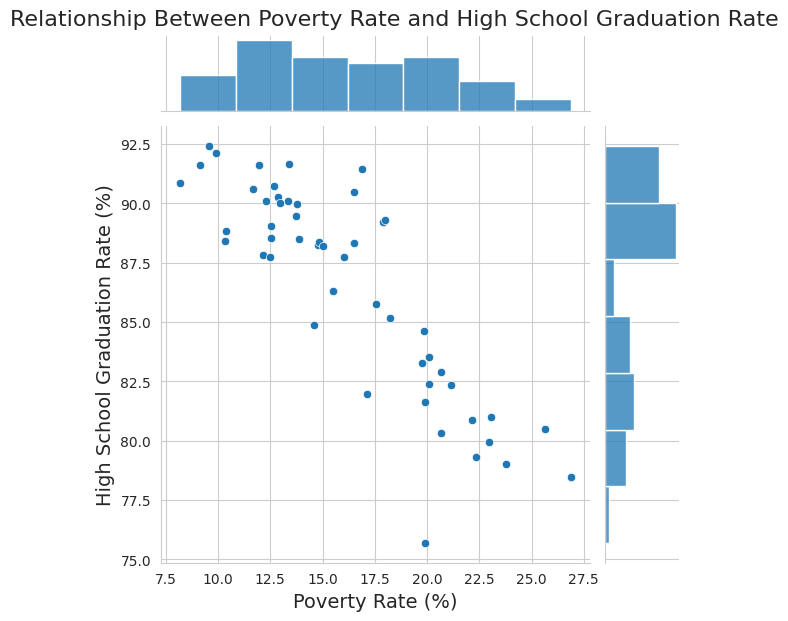

In [42]:
with sns.axes_style("whitegrid"):
  sns.jointplot(x=merged_df.poverty_rate,
                y=merged_df.percent_completed_hs,
  )
  plt.xlabel("Poverty Rate (%)", fontsize=14)
  plt.ylabel("High School Graduation Rate (%)", fontsize=14)
  plt.suptitle(
      "Relationship Between Poverty Rate and High School Graduation Rate",
      fontsize=16,
      y=1.02
  )

#### Seaborn's `.lmplot()` or `.regplot()` to show a linear regression between the poverty ratio and the high school graduation ratio.

Text(0.05, 0.95, 'Correlation: -0.86')

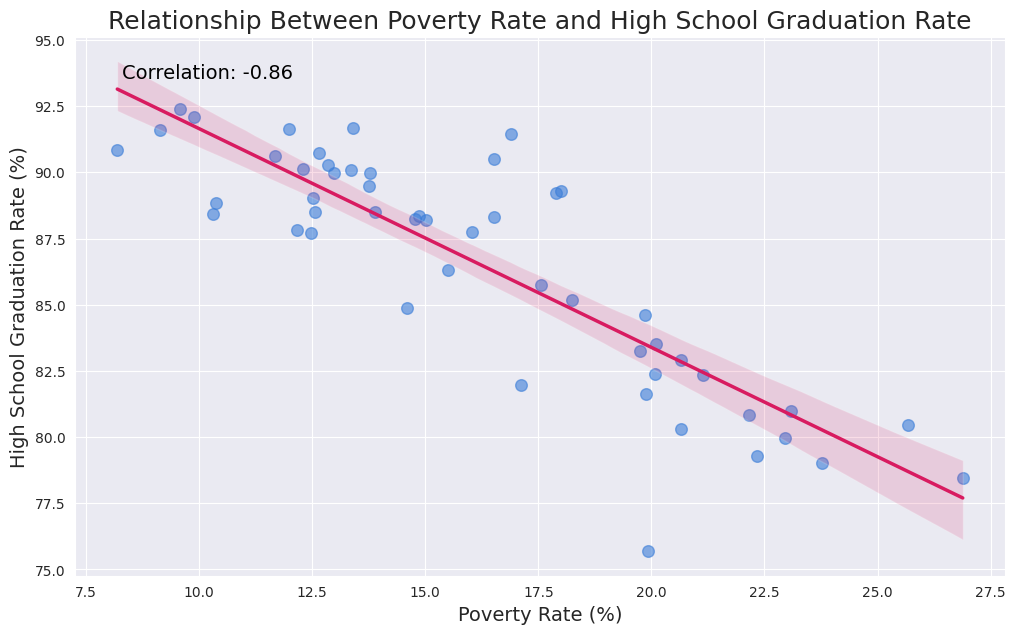

In [43]:
sns.set_style("darkgrid")
plt.figure(figsize=(12, 7))


sns.regplot(
    data=merged_df,
    x="poverty_rate",
    y="percent_completed_hs",
    scatter_kws={'alpha': 0.6, 's': 70, 'color': '#3b7dd8'},
    line_kws={'color': '#d81b60', 'linewidth': 2.5}
)

plt.title("Relationship Between Poverty Rate and High School Graduation Rate", fontsize=18)
plt.xlabel("Poverty Rate (%)", fontsize=14)
plt.ylabel("High School Graduation Rate (%)", fontsize=14)

corr = merged_df["poverty_rate"].corr(merged_df["percent_completed_hs"])
plt.text(
    0.05, 0.95,
    f"Correlation: {corr:.2f}",
    transform=plt.gca().transAxes,
    fontsize=14,
    color="black",
    verticalalignment='top'
)


# Create a Bar Chart with Subsections Showing the Racial Makeup of Each US State

Visualise the share of the white, black, hispanic, asian and native american population in each US State using a bar chart with sub sections.

In [44]:
df_race =df_fatalities.groupby(["state", "race"]).size().unstack(fill_value=0)
df_race

race,0,A,B,H,N,O,W
state,,,,,,,
AK,1,0,1,0,6,0,7
AL,4,0,14,0,0,0,32
AR,4,0,6,0,0,0,16
AZ,11,0,5,37,8,0,57
CA,41,15,65,169,1,8,125
CO,10,2,8,21,1,0,32
CT,2,0,0,2,0,0,5
DC,0,0,10,0,0,0,1
DE,0,0,4,0,0,0,4


In [45]:
fig = px.bar(
    df_race,
    x=df_race.index,
    y=df_race.columns,
    title="Share of Population by Race in Each US State",
    labels={"value": "Count", "state": "State", "variable": "Race"},
    color_discrete_sequence=px.colors.qualitative.Pastel2

)
fig.update_layout(
    barmode="stack",
    xaxis_title="State",
    yaxis_title="Number of People",
    legend_title="Race",
    width=1200,
    height=700
)
fig.show()

# Create Donut Chart by of People Killed by Race

Hint: Use `.value_counts()`

In [46]:
vc_race=df_fatalities["race"].value_counts()
vc_race

,count
race,
W,1201
B,618
H,423
0,195
A,39
N,31
O,28


In [47]:
fig = px.pie(
    names=vc_race.index,
    values=vc_race.values,
    hole=0.45,
    title="Distribution of Fatalities by Race",
    color_discrete_sequence=px.colors.qualitative.Set3
)


fig.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

fig.update_layout(
    showlegend=False,
    width=650,
    height=650,
    title_x=0.5
    )

# Create a Chart Comparing the Total Number of Deaths of Men and Women

Use `df_fatalities` to illustrate how many more men are killed compared to women.

In [48]:
men_vs_women=df_fatalities["gender"].value_counts()

In [49]:
fig = px.bar(
    x=men_vs_women.index,
    y=men_vs_women.values,
    title="Comparison of Men vs Women",
    labels={"x": "Category", "y": "Count"},
    text=men_vs_women.values,
    color=men_vs_women.index,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(
    title_x=0.5,
    xaxis_title="Category",
    yaxis_title="Number of People",
    showlegend=False
)

fig.show()

# Create a Bar Chart Showing the Age and Manner of Death

Break out the data by gender using `df_fatalities`. Is there a difference between men and women in the manner of death?

In [50]:
#df_fatalities.groupby(["gender","manner_of_death"]).agg({"id":pd.Series.count})
manner=df_fatalities.groupby(["gender","manner_of_death"]).size().unstack(fill_value=0)
manner

manner_of_death,shot,shot and Tasered
gender,,
F,102,5
M,2261,167


In [51]:
fig = px.bar(
    manner,
    barmode="group",
    title="Manner of Death by Gender"
)
fig.show()

# Were People Armed?

In what percentage of police killings were people armed? Create chart that show what kind of weapon (if any) the deceased was carrying. How many of the people killed by police were armed with guns versus unarmed?

In [54]:
armed=df_fatalities.armed.value_counts()

In [69]:
fig=px.bar(x=armed.index,
       y=armed.values,
       text=armed.values,
       title="Weapons Carried by People Killed by Police",
    labels={"y": "Number of Fatalities", "x": "Weapon Type"},
    color=armed.values,
       color_continuous_scale="Blues")

fig.update_traces(
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>Count: %{x}<extra></extra>"
)

fig.show()

In [77]:
grouped_armed=df_fatalities[df_fatalities['armed'].isin(['gun', 'unarmed'])]
df_armed=grouped_armed.armed.value_counts()

In [81]:
fig=px.bar(x=df_armed.index,
       y=df_armed.values,
       text=df_armed.values,
       title="How Many People were Armed vs Unarmed?",
    labels={"y": "Number of Fatalities", "x": "Weapon Type"},
    color=df_armed.values,
       color_continuous_scale="Blues")

fig.update_traces(
    textposition="outside",
    hovertemplate="<b>%{y}</b><br>Count: %{x}<extra></extra>"
)

fig.show()

# How Old Were the People Killed?

Work out what percentage of people killed were under 25 years old.  

In [93]:
people_under_25=df_fatalities[df_fatalities.age<25].shape[0]
ingesamt_people=df_fatalities.shape[0]
print(f'Percentage of people killed by the police under the age of 25 is: {round(people_under_25/ingesamt_people*100,2)}%')

Percentage of people killed by the police under the age of 25 is: 20.79%


Create a histogram and KDE plot that shows the distribution of ages of the people killed by police.

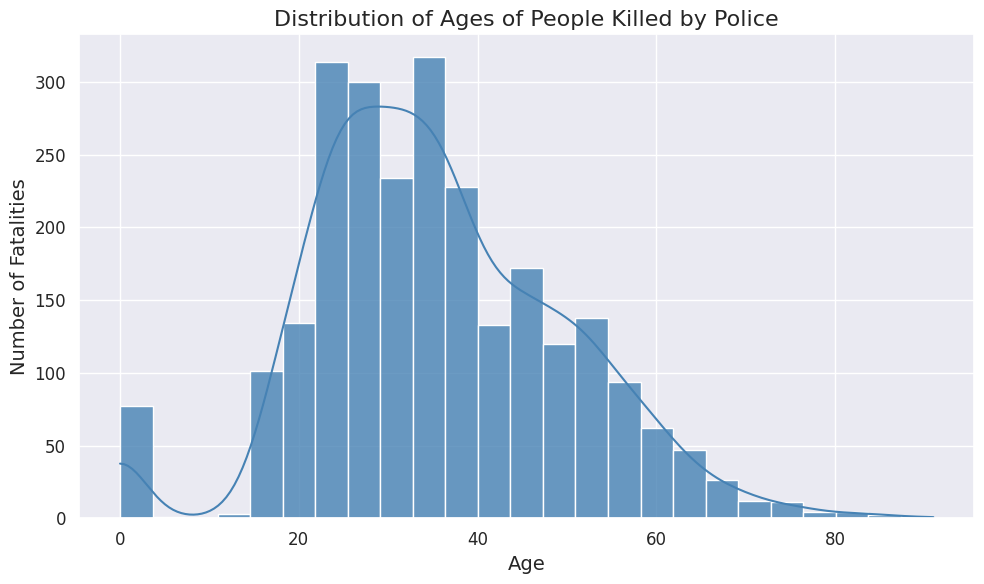

In [100]:
ages = df_fatalities["age"].dropna()

sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
sns.histplot(
    ages,
    kde=True,
    bins=25,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)

plt.title("Distribution of Ages of People Killed by Police", fontsize=16)
plt.xlabel("Age", fontsize=14)
plt.ylabel("Number of Fatalities", fontsize=14)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()


Create a seperate KDE plot for each race. Is there a difference between the distributions?

<Figure size 1200x800 with 0 Axes>

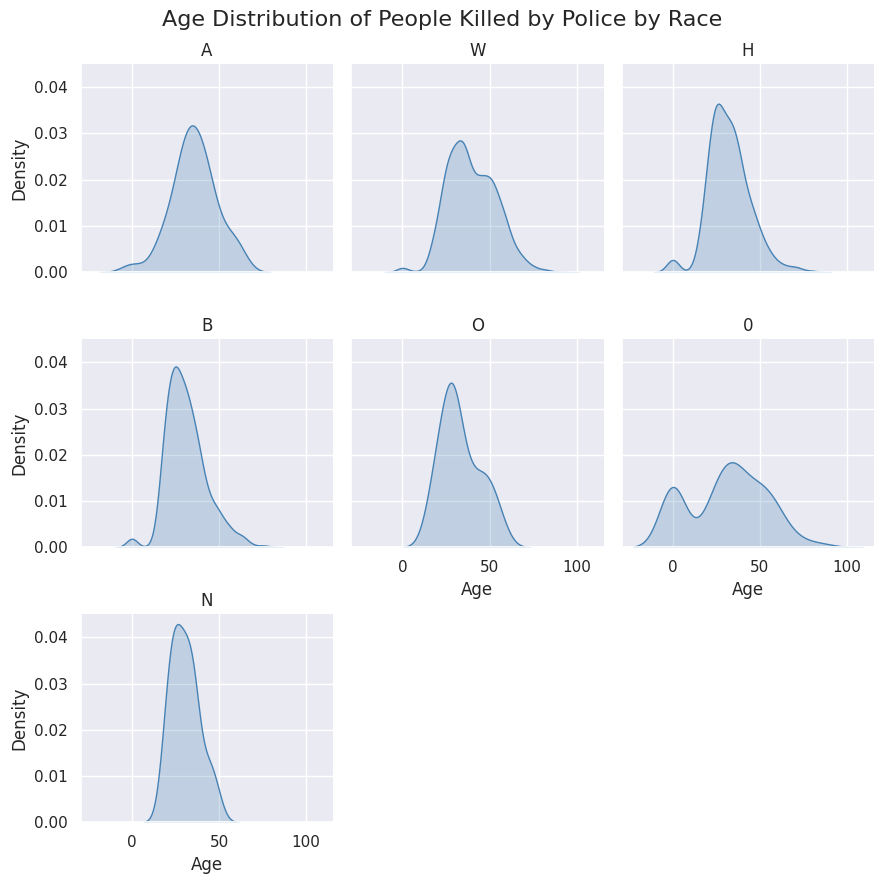

In [98]:
df_kde = df_fatalities.dropna(subset=["age", "race"])

sns.set_theme(style="darkgrid")

plt.figure(figsize=(12, 8))
g = sns.FacetGrid(
    df_kde,
    col="race",
    col_wrap=3,
    sharex=True,
    sharey=True,
    height=3
)

g.map(sns.kdeplot, "age", fill=True, color="steelblue")

g.set_titles(col_template="{col_name}")
g.set_axis_labels("Age", "Density")

plt.subplots_adjust(top=0.92)
g.fig.suptitle("Age Distribution of People Killed by Police by Race", fontsize=16)

plt.show()

# Mental Illness and Police Killings

What percentage of people killed by police have been diagnosed with a mental illness?

In [110]:
illness_true=df_fatalities[df_fatalities['signs_of_mental_illness']==True].shape[0]
illness_false=df_fatalities[df_fatalities['signs_of_mental_illness']==False].shape[0]

In [111]:
print(f'Percentage of people killed by the police with signs of mental illness: {round(illness_true/illness_false*100,2)}%')

Percentage of people killed by the police with signs of mental illness: 33.28%


# In Which Cities Do the Most Police Killings Take Place?

Create a chart ranking the top 10 cities with the most police killings. Which cities are the most dangerous?  

In [122]:
dangerous_cities=df_fatalities.groupby("city",as_index=False).agg({"id":pd.Series.count})
dangerous_cities.sort_values("id",ascending=False,inplace=True)


top10=dangerous_cities.head(10)

In [123]:
fig = px.bar(
    top10,
    x="id",
    y="city",
    orientation="h",
    text="id",
    title="Top 10 U.S. Cities With the Most Police Killings",
    labels={"id": "Number of Fatalities", "city": "City"},
    color="id",
    color_continuous_scale="Reds"
)

fig.update_traces(textposition="outside")

fig.show()

# Rate of Death by Race

Find the share of each race in the top 10 cities. Contrast this with the top 10 cities of police killings to work out the rate at which people are killed by race for each city.

In [129]:
top10_cities = df_fatalities[df_fatalities["city"].isin(top10["city"])]

In [137]:
race_city_share =top10_cities.groupby(["city", "race"])["id"].count().reset_index(name="count")

race_city_share["share_%"] =race_city_share.groupby("city")["count"].transform(lambda x: x / x.sum() * 100)

In [136]:
race_city_share

,city,race,count,share_%
0,Austin,B,3,16.67
1,Austin,H,2,11.11
2,Austin,W,13,72.22
3,Chicago,0,1,4.00
4,Chicago,B,21,84.00
5,Chicago,H,1,4.00
6,Chicago,W,2,8.00
7,Columbus,0,1,5.26
8,Columbus,B,11,57.89
9,Columbus,O,1,5.26


# Create a Choropleth Map of Police Killings by US State

Which states are the most dangerous? Compare your map with your previous chart. Are these the same states with high degrees of poverty?

In [140]:
state_killings =df_fatalities.groupby("state", as_index=False).agg({"id": "count"}).rename(columns={"id": "fatalities"})

In [144]:

fig = px.choropleth(
    state_killings,
    locations="state",
    locationmode="USA-states",
    color="fatalities",
    color_continuous_scale="Reds",
    scope="usa",
    labels={"fatalities": "Police Killings"},
    title="Police Killings by U.S. State"
)

fig.show()

# Number of Police Killings Over Time

Analyse the Number of Police Killings over Time. Is there a trend in the data?

/tmp/ipython-input-4024159674.py:2: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



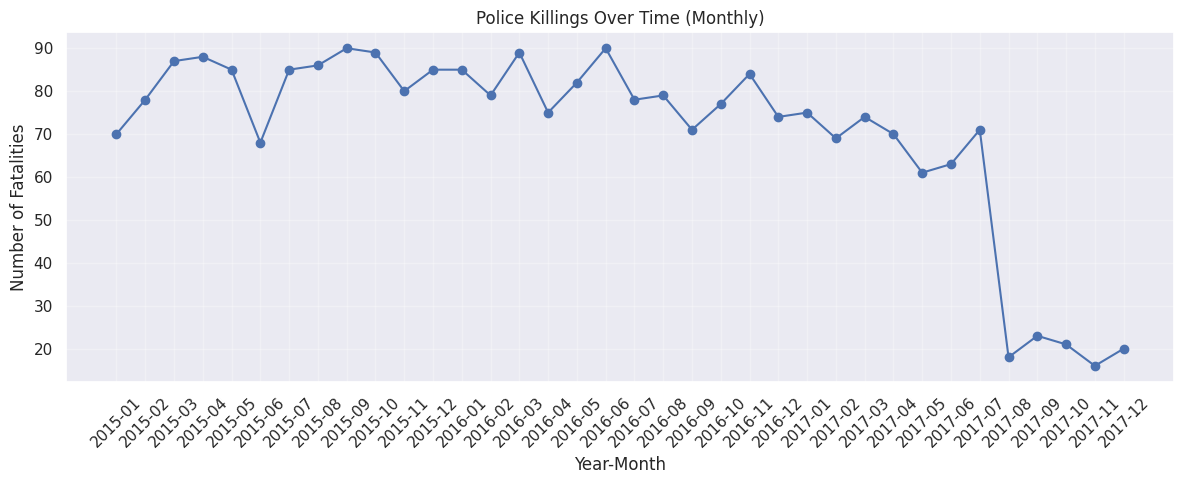

In [164]:
over_time = df_fatalities.copy()
over_time["date"] = pd.to_datetime(over_time["date"])
over_time["year_month"] = over_time["date"].dt.to_period("M").astype(str)

monthly = over_time.groupby("year_month")["id"].count().reset_index(name="fatalities")


plt.figure(figsize=(12, 5))
plt.plot(monthly["year_month"], monthly["fatalities"], marker="o")
plt.title("Police Killings Over Time (Monthly)")
plt.xlabel("Year-Month")
plt.ylabel("Number of Fatalities")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
